# Assignment Module 2: Pet Classification

The goal of this assignment is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [Oxford-IIIT-Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). The assignment is divided into two parts: first, you will be asked to implement from scratch your own neural network for image classification; then, you will fine-tune a pretrained network provided by PyTorch.

### Notebook Mode: Training or Loading
Set this global variable to True is the training has to be done and to False is the training has already been done and you only want to load the model weights.

In [114]:
TRAINING_REQUIRED = True

### Import

In [115]:
!git clone https://github.com/CVLAB-Unibo/ipcv-assignment-2.git

fatal: destination path 'ipcv-assignment-2' already exists and is not an empty directory.


In [116]:
!pip install -q wandb
!pip install -q torchmetrics

In [117]:
from pathlib import Path
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from typing import Any, Callable, Dict, List, Optional, Tuple
import random
import time
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.utils.data import random_split, DataLoader
from torchvision import transforms as T, datasets
import torchvision.transforms.v2 as v2
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau, CosineAnnealingLR
from torchmetrics.classification.accuracy import Accuracy
import copy
from torchvision.models import resnet18, ResNet18_Weights
import wandb

print("Using torch", torch.__version__)

Using torch 2.6.0+cu124


### Dataset

The following cells contain the code to download and access the dataset you will be using in this assignment. Note that, although this dataset features each and every image from [Oxford-IIIT-Pet](https://www.robots.ox.ac.uk/~vgg/data/pets/), it uses a different train-val-test split than the original authors.

In [118]:
class OxfordPetDataset(Dataset):
    def __init__(self, split: str, transform=None) -> None:
        super().__init__()

        self.root = Path("ipcv-assignment-2") / "dataset"
        self.split = split
        self.names, self.labels = self._get_names_and_labels()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx) -> Tuple[Tensor, int]:
        img_path = self.root / "images" / f"{self.names[idx]}.jpg"
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

    def get_num_classes(self) -> int:
        return max(self.labels) + 1

    def _get_names_and_labels(self) -> Tuple[List[str], List[int]]:
        names = []
        labels = []

        with open(self.root / "annotations" / f"{self.split}.txt") as f:
            for line in f:
                name, label = line.replace("\n", "").split(" ")
                names.append(name),
                labels.append(int(label) - 1)

        return names, labels

In [119]:
def get_dataloaders(train_transformer,test_transformer, batch_size):

    # --- Datasets ---
    train_dset = OxfordPetDataset(
        split="train",
        transform=train_transformer
    )
    val_dset = OxfordPetDataset(
        split="val",
        transform=test_transformer,
    )
    test_dset = OxfordPetDataset(
        split="test",
        transform=test_transformer,
    )

    # --- DataLoaders ---
    train_dl = DataLoader(
        train_dset,
        batch_size=batch_size,
        shuffle=True
    )
    val_dl = DataLoader(
        val_dset,
        batch_size=batch_size
    )
    test_dl = DataLoader(
        test_dset,
        batch_size=batch_size
    )

    return train_dl, val_dl, test_dl

### Fix randomness

In [120]:
def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

fix_random(33)

### GPU check

In [121]:
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Is the GPU available? True
Device: cuda


### Free memory

In [122]:
import gc

torch.cuda.empty_cache()
gc.collect()

40776

### Trainer class

In [123]:
class Trainer:
    def __init__(self,
                 model: nn.Module,
                 train_loader: DataLoader,
                 val_loader: DataLoader,
                 test_loader: DataLoader,
                 device: torch.device,
                 model_file_name: str,
                 num_classes: int,
                 cfg: Dict[str, Any],
                 wandb_credentials: Optional[Tuple[str, str]] = None,
                 verbose: bool = False,
                 ) -> None:

        # Loaders
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader

        # Model to device
        self.device = device
        self.model = model.to(device)
        self.best_model = copy.deepcopy(self.model)
        self.best_state_dict = copy.deepcopy(self.model.state_dict())
        self.model_file_name = model_file_name

        # Classes
        self.num_classes = num_classes

        # Epochs
        self.num_epochs = cfg["num_epochs"]

        # Optimizer
        self.optimizer = AdamW(self.model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

        # Scheduler
        if cfg["scheduler"]:
            num_steps = self.num_epochs * len(train_loader)
            self.scheduler = OneCycleLR(self.optimizer, cfg["lr"], total_steps=num_steps)
        else:
            # Dummy scheduler che non fa nulla
            from torch.optim.lr_scheduler import LambdaLR
            self.scheduler = LambdaLR(self.optimizer, lr_lambda=lambda epoch: 1.0)
            

        # Batch transformations (MixUp, CutMix, ...)
        self.batch_transforms = cfg["batch_transforms"]

        # Stats
        self.step = 0
        self.best_acc = 0.0
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []

        # Wandb credentials
        self.wandb_credentials = wandb_credentials
        if self.wandb_credentials is not None:
          WANDB_USER, WANDB_PROJECT = self.wandb_credentials
          wandb.init(name=cfg["run_name"], entity=WANDB_USER, project=WANDB_PROJECT, config=cfg)

        # Path for saving model
        self.ckpt_path = Path("ckpts")
        self.ckpt_path.mkdir(exist_ok=True)

        # Verbose
        self.verbose = verbose


    def logfn(self, values: Dict[str, Any]) -> None:
        wandb.log(values, step=self.step, commit=False)

    def train(self) -> None:
        for _ in tqdm(range(self.num_epochs), desc="Epoch"):
            self.model.train()

            for imgs, labels in self.train_loader:
                imgs = imgs.to(self.device)
                labels = labels.to(self.device)

                if self.batch_transforms:
                  imgs, labels = self.batch_transforms(imgs, labels)

                pred = self.model(imgs)
                loss = F.cross_entropy(pred, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.scheduler.step()

                if self.wandb_credentials:
                    self.logfn({"train/loss": loss.item()})
                    self.logfn({"train/lr": self.scheduler.get_last_lr()[0]})

                self.step += 1

            if self.verbose:
              print(f"Epoch {_+1}")

            train_loss, train_accuracy = self.eval("train")
            val_loss, val_accuracy = self.eval("val")

            self.train_loss.append(train_loss)
            self.train_acc.append(train_accuracy)
            self.val_loss.append(val_loss)
            self.val_acc.append(val_accuracy)

        if self.wandb_credentials:
          wandb.finish()

    @torch.no_grad()
    def eval(self, split: str) -> Tuple[float, float]:
    
        if split == "test":
            self.best_model.load_state_dict(self.best_state_dict)
            model_to_eval = self.best_model

        else:
            model_to_eval = self.model
    
        model_to_eval.eval()
    
        loader = (
            self.train_loader if split == "train"
            else self.val_loader if split == "val"
            else self.test_loader
        )
    
        losses = []
        correct = 0
        total = 0
    
        for imgs, labels in loader:
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)
    
            pred = model_to_eval(imgs)
            loss = F.cross_entropy(pred, labels)
            losses.append(loss.item())
    
            # accuracy al volo, senza softmax
            preds = pred.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
        loss = sum(losses) / len(losses)
        accuracy = correct / total
    
        if self.wandb_credentials:
            self.logfn({f"{split} loss": loss})
            self.logfn({f"{split} acc": accuracy})
        elif self.verbose:
            print(f"\t{split} loss {loss:.3f} - {split} accuracy {accuracy:.3f}")
    
        # if accuracy > self.best_acc and split == "val":
        #     self.best_acc = accuracy
        #     if self.wandb_credentials:
        #         torch.save(model_to_eval.state_dict(), self.ckpt_path / f"{wandb.run.name}.pth")
        #     else:
        #         torch.save(model_to_eval.state_dict(), self.ckpt_path / "best_model.pth")
    
        #     self.best_model = copy.deepcopy(model_to_eval)

        if accuracy > self.best_acc and split == "val":
            self.best_acc = accuracy

            self.best_state_dict = copy.deepcopy(model_to_eval.state_dict())
            if self.wandb_credentials:
                torch.save(self.best_state_dict, self.ckpt_path / f"{wandb.run.name}.pth")
            else:
                torch.save(self.best_state_dict, self.ckpt_path / f"{self.model_file_name}.pth")
        
    
        return loss, accuracy

    def load(self, path: str):
        
        self.best_state_dict = torch.load(path)
        self.model.load_state_dict(self.best_state_dict)
        

### Plot the history

In [124]:
def plot_history(history):

  fig, axes = plt.subplots(1, 2, figsize=(10,4))

  # Loss
  axes[0].plot(history["train_loss"], label="train")
  if history["val_loss"]:
      axes[0].plot(history["val_loss"], label="val")
  axes[0].set_title("Loss")
  axes[0].legend()

  # Accuracy
  axes[1].plot(history["train_acc"], label="train")
  if history["val_acc"]:
      axes[1].plot(history["val_acc"], label="val")
  axes[1].set_title("Accuracy")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `OxfordPetDataset`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~60%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~60% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

### CNN Architecture

Definition of our architecture. We are going to use a ResNet.

In [125]:
# --- Residual Blocks ---

class BasicBlock(nn.Module): #basic convolutional block (conv+relu), neither batch normalization nor skip connections whatsoever

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.downsample = downsample

    def forward(self, x):

        out = self.conv1(x)
        out = torch.relu(out)
        out = self.conv2(out)
        out = torch.relu(out)
        
        return out

class BatchNormBlock(nn.Module): #basic convolutional block + batch normalization.

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)
        out = self.bn2(out)
        out = torch.relu(out)
        
        return out
    

class ResidualBlock(nn.Module): #residual block (BN + skip connections) but without bottleneck

    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out



class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = torch.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = torch.relu(out)
        return out


# --- General CNN ---

class CNN(nn.Module):
    def __init__(self, block, layers, num_classes=37, input_channels=3, dropout=0.5):
        super(CNN, self).__init__()
        self.in_channels = 64

        # Initial stem
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Adaptive pooling for variable input size
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


In [126]:
#we create a dictionary to store the performance metrics which we'll plot at the end
models_performance = {}

### Model B: best model

Architecture:
- resnet [2,3,4,2]
- normal residual blocks

Regularization and training recipes:
- dropout
- weight decay
- scheduler
- trivial augmentation
- mixup
- cutmix
- random erasing



In [127]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_B = {
    # Pre-processing's parameters.
    "resize_size": 256,
    "crop_size": 224,

    # Training's parameters.
    "batch_size": 128,
    "num_epochs": 2,

    # Optimizer's parameters.
    "lr": 1e-3,
    "wd": 1e-4,
    "step_size": 5,

    # Batch transformations
    "batch_transforms" : v2.Compose([
        v2.MixUp(alpha=1.0, num_classes=n_classes),     # MIXUP
        v2.CutMix(alpha=1.0, num_classes=n_classes),    # CUTMIX
    ]),

    # Scheduler
    "scheduler":True,

    # Model
    'block_type': ResidualBlock,
    'block_depths': [2, 3, 4, 2],
    'num_classes': n_classes,
    'input_channels': 3,
    'dropout': 0.5
}

# --- Transform for Data Augmentation and Img Resizing ---

train_transformer_B = T.Compose([
    T.RandomResizedCrop(cfg_B["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.RandomHorizontalFlip(),                       # TRIVIAL AUGMENTATION
    T.ToTensor(),
    T.ConvertImageDtype(torch.float),
    T.RandomErasing(p=0.5,                          # RANDOM ERASING
                    scale=(0.02, 0.33),
                    ratio=(0.3, 3.3),
                    value=0,
                    inplace=False),
])

test_transformer_B = T.Compose([
    T.Resize(cfg_B["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_B["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_B, val_dl_B, test_dl_B = get_dataloaders(train_transformer_B,
                                               test_transformer_B,
                                               cfg_B["batch_size"])

# --- Model ---

model_B = CNN(cfg_B['block_type'],
             cfg_B['block_depths'],
             cfg_B['num_classes'],
             cfg_B['input_channels'],
             cfg_B['dropout'])

trainer_B = Trainer(
    model=model_B,
    train_loader=train_dl_B,
    val_loader=val_dl_B,
    test_loader=test_dl_B,
    device=device,
    num_classes=n_classes,
    cfg=cfg_B,
    verbose=False,
    model_file_name='model_B'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_B.train()
else:
    trainer_B.load("ckpts/model_B.pth")

# --- Evaluation ---

test_loss, test_accuracy = trainer_B.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_B'] = {
    'test_accuracy': test_accuracy,
    'flag': 'best',
    'label': 'Best Model'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.085


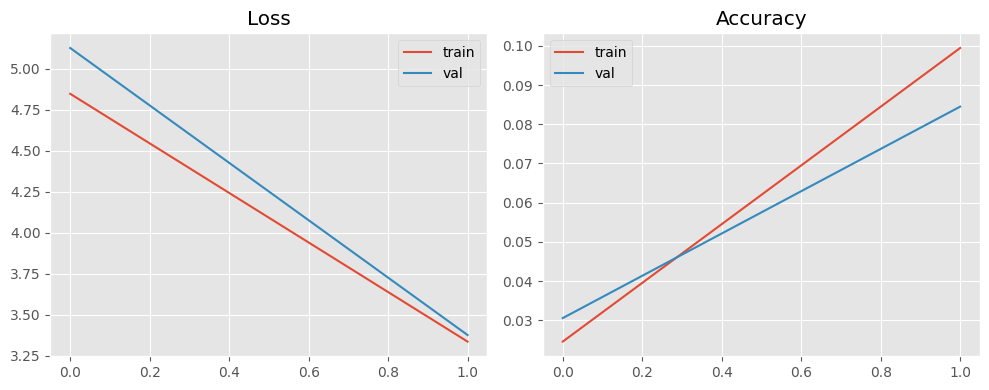

In [128]:
history_B = {
    "train_loss":trainer_B.train_loss,
    "train_acc":trainer_B.train_acc,
    "val_loss":trainer_B.val_loss,
    "val_acc":trainer_B.val_acc
}

plot_history(history_B)

## ABLATION STUDIES

We are going to perform ablation studies both on the architecture (trying different depths and different types of convolutional blocks) and on the regularization and training recipes.
Our goal is to see what of the components of our network actually contributed to the high performance we got.

### Model C: a very shallow resnet

We want to show what happens when we use a very shallow ResNet, with residual blocks (no bottleneck, just like our best model).

In [129]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_C = cfg_B
cfg_C['block_depths'] = [1,1,1,1]
train_dl_C = train_dl_B
val_dl_C = val_dl_B
test_dl_C = test_dl_B

model_C = CNN(cfg_C['block_type'],
             cfg_C['block_depths'],
             cfg_C['num_classes'],
             cfg_C['input_channels'],
             cfg_C['dropout'])

trainer_C = Trainer(
    model=model_C,
    train_loader=train_dl_C,
    val_loader=val_dl_C,
    test_loader=test_dl_C,
    device=device,
    num_classes=n_classes,
    cfg=cfg_C,
    verbose=False,
    model_file_name='model_C'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_C.train()
else:
    trainer_C.load("ckpts/model_C.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_C.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_C'] = {
    'test_accuracy': test_accuracy,
    'flag': 'architecture',
    'label': 'Shallow ResNet'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.097


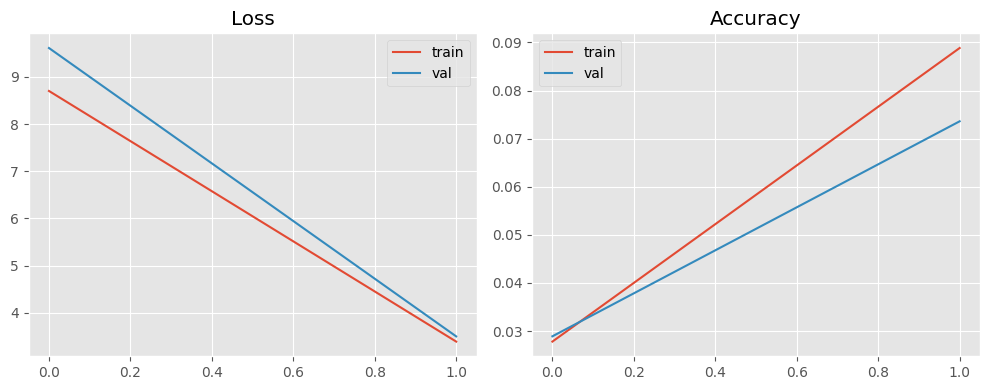

In [130]:
history_C = {
    "train_loss":trainer_C.train_loss,
    "train_acc":trainer_C.train_acc,
    "val_loss":trainer_C.val_loss,
    "val_acc":trainer_C.val_acc
}

plot_history(history_C)

Despite halving the depth of the network, the performance of this shallow ResNet did not drop excessively.

### Model D, E and F: best network obtained (resnset20 with residual blocks) but with 3 different blocks: basic, batchnorm, bottleneck

In [131]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

#we copy the configuration and dataloaders of our 'ultimate' model, modifying the block_type field
cfg_D = cfg_E = cfg_F = cfg_B

cfg_D['block_type'] = BasicBlock
cfg_E['block_type'] = BatchNormBlock
cfg_F['block_type'] = Bottleneck

# --- DataLoaders ---
train_dl_D = train_dl_E = train_dl_F = train_dl_B
val_dl_D = val_dl_E = val_dl_F = val_dl_B
test_dl_D = test_dl_E = test_dl_F = test_dl_B

In [132]:
#MODEL D: BasicBlock without BatchNormalization and SkipConnections 
# --- Model ---

model_D = CNN(cfg_D['block_type'],
             cfg_D['block_depths'],
             cfg_D['num_classes'],
             cfg_D['input_channels'],
             cfg_D['dropout'])

trainer_D = Trainer(
    model=model_D,
    train_loader=train_dl_D,
    val_loader=val_dl_D,
    test_loader=test_dl_D,
    device=device,
    num_classes=n_classes,
    cfg=cfg_D,
    verbose=False,
    model_file_name='model_D'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_D.train()
else:
    trainer_D.load("ckpts/model_D.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_D.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_D'] = {
    'test_accuracy': test_accuracy,
    'flag': 'architecture',
    'label': 'Basic Block Network'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.101


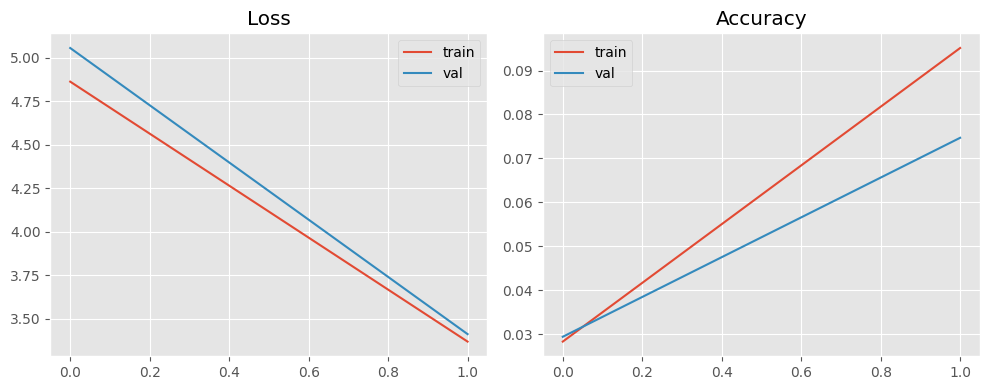

In [133]:
history_D = {
    "train_loss":trainer_D.train_loss,
    "train_acc":trainer_D.train_acc,
    "val_loss":trainer_D.val_loss,
    "val_acc":trainer_D.val_acc
}

plot_history(history_D)

In [134]:
#MODEL E: BasicBlock with BN
# --- Model ---

model_E = CNN(cfg_E['block_type'],
             cfg_E['block_depths'],
             cfg_E['num_classes'],
             cfg_E['input_channels'],
             cfg_E['dropout'])

trainer_E = Trainer(
    model=model_E,
    train_loader=train_dl_E,
    val_loader=val_dl_E,
    test_loader=test_dl_E,
    device=device,
    num_classes=n_classes,
    cfg=cfg_E,
    verbose=False,
    model_file_name='model_E'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_E.train()
else:
    trainer_E.load("ckpts/model_E.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_E.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_E'] = {
    'test_accuracy': test_accuracy,
    'flag': 'architecture',
    'label': 'Batch Norm Network'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.103


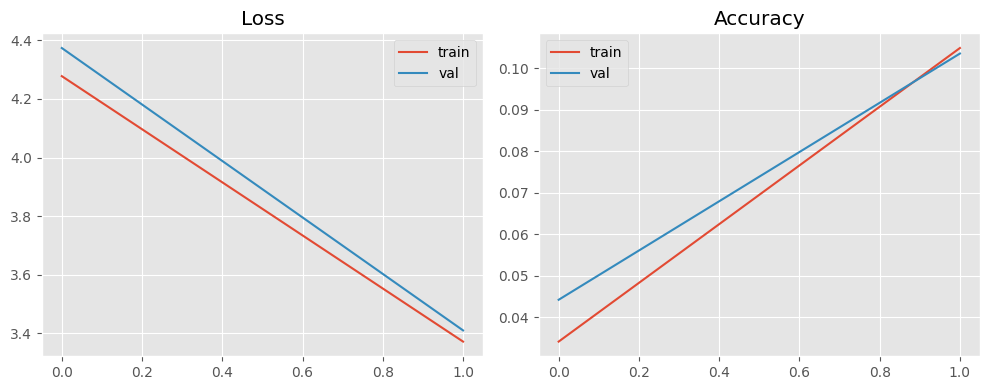

In [135]:
history_E = {
    "train_loss":trainer_E.train_loss,
    "train_acc":trainer_E.train_acc,
    "val_loss":trainer_E.val_loss,
    "val_acc":trainer_E.val_acc
}

plot_history(history_E)

In [136]:
#MODEL F: Bottleneck 
# --- Model ---

model_F = CNN(cfg_F['block_type'],
             cfg_F['block_depths'],
             cfg_F['num_classes'],
             cfg_F['input_channels'],
             cfg_F['dropout'])

trainer_F = Trainer(
    model=model_F,
    train_loader=train_dl_F,
    val_loader=val_dl_F,
    test_loader=test_dl_F,
    device=device,
    num_classes=n_classes,
    cfg=cfg_F,
    verbose=False,
    model_file_name='model_F'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_F.train()
else:
    trainer_F.load("ckpts/model_F.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_F.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_F'] = {
    'test_accuracy': test_accuracy,
    'flag': 'architecture',
    'label': 'Bottleneck ResNet'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.078


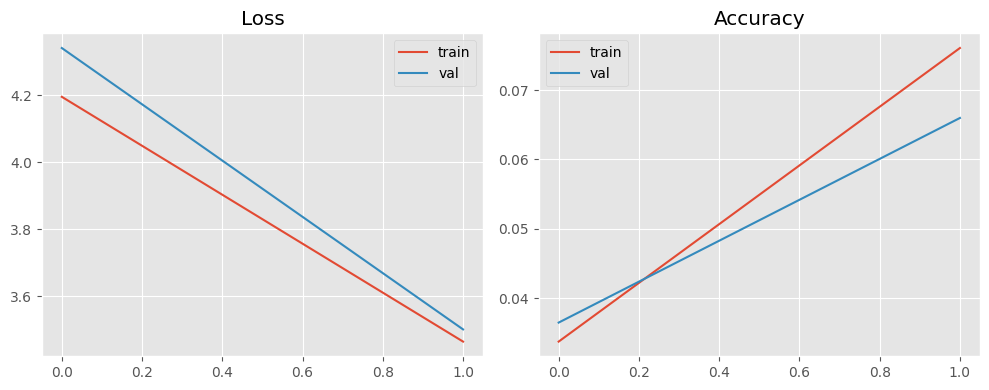

In [137]:
history_F = {
    "train_loss":trainer_F.train_loss,
    "train_acc":trainer_F.train_acc,
    "val_loss":trainer_F.val_loss,
    "val_acc":trainer_F.val_acc
}

plot_history(history_F)

### Ablation on generalization and training recipes

We now try to remove some of the training recipes we employed in our best netork.

### Model G: remove MixUp, CutMix, Horizontal Flip, Random Erasing

In [138]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---
cfg_G = cfg_B
cfg_G['batch_transforms'] = None
#we remove most of the data augmentation techniques
train_transformer_G = T.Compose([
    T.RandomResizedCrop(cfg_G["crop_size"], scale=(0.8, 1.0)),     # RANDOM CROP RESIZE
    T.ToTensor(),
])

test_transformer_G = T.Compose([
    T.Resize(cfg_G["resize_size"]),                                  # RESIZE
    T.CenterCrop(cfg_G["crop_size"]),                              # CENTER CROP
    T.ToTensor(),
])

# --- DataLoaders ---

train_dl_G, val_dl_G, test_dl_G = get_dataloaders(train_transformer_G,
                                               test_transformer_G,
                                               cfg_G["batch_size"])

# --- Model ---

model_G = CNN(cfg_G['block_type'],
             cfg_G['block_depths'],
             cfg_G['num_classes'],
             cfg_G['input_channels'],
             cfg_G['dropout'])

trainer_G = Trainer(
    model=model_G,
    train_loader=train_dl_G,
    val_loader=val_dl_G,
    test_loader=test_dl_G,
    device=device,
    num_classes=n_classes,
    cfg=cfg_G,
    verbose=False,
    model_file_name='model_G'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_G.train()
else:
    trainer_G.load("ckpts/model_G.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_G.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_G'] = {
    'test_accuracy': test_accuracy,
    'flag': 'recipes',
    'label': 'No data augmentation'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.153


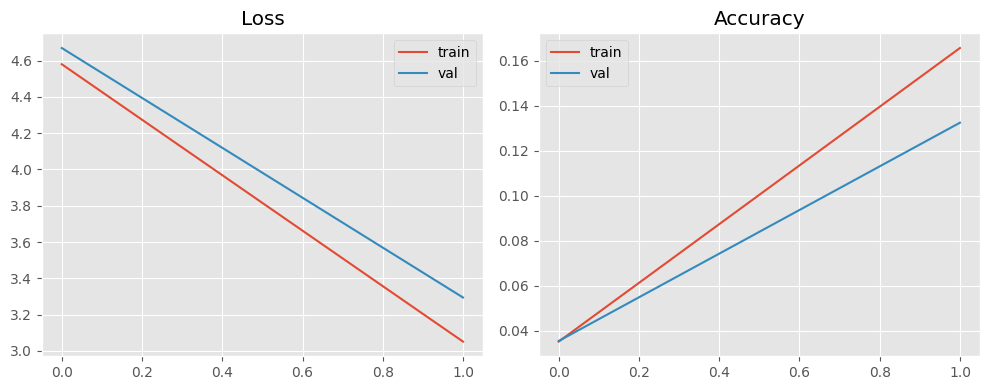

In [139]:
history_G = {
    "train_loss":trainer_G.train_loss,
    "train_acc":trainer_G.train_acc,
    "val_loss":trainer_G.val_loss,
    "val_acc":trainer_G.val_acc
}

plot_history(history_G)

### Model H: No Dropout, No scheduler, No weight decay

In [146]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

#we copy the configuration and dataloaders of our 'ultimate' model, modifying the block_type field
cfg_H = cfg_B

cfg_H['dropout'] = 0
cfg_H['wd'] = 0.0
cfg_H['scheduler']= False

# --- DataLoaders ---
train_dl_H = train_dl_B
val_dl_H = val_dl_B
test_dl_H = test_dl_B

#MODEL H: our best model but without dropout
# --- Model ---

model_H = CNN(cfg_H['block_type'],
             cfg_H['block_depths'],
             cfg_H['num_classes'],
             cfg_H['input_channels'],
             cfg_H['dropout'])

trainer_H = Trainer(
    model=model_H,
    train_loader=train_dl_H,
    val_loader=val_dl_H,
    test_loader=test_dl_H,
    device=device,
    num_classes=n_classes,
    cfg=cfg_H,
    verbose=False,
    model_file_name='model_H'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_H.train()
else:
    trainer_H.load("ckpts/model_H.pth")
    
# --- Evaluation ---

test_loss, test_accuracy = trainer_H.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

models_performance['model_H'] = {
    'test_accuracy': test_accuracy,
    'flag': 'recipes',
    'label': 'No dropout, no scheduler, no weight decay'
}

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.101


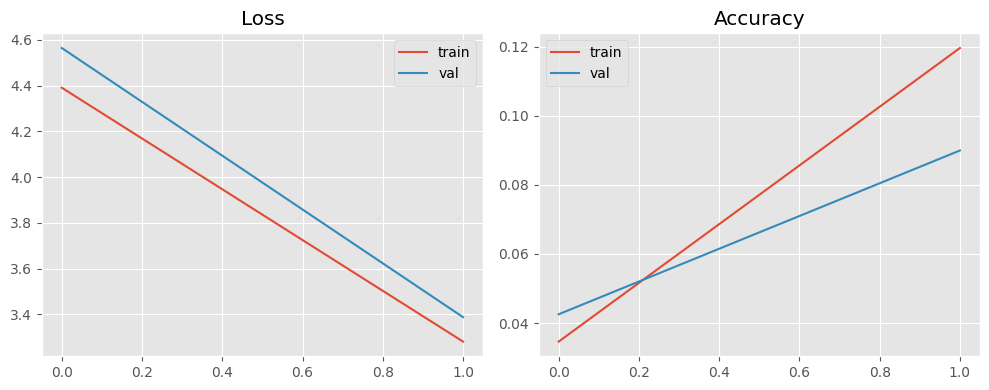

In [147]:
history_H = {
    "train_loss":trainer_H.train_loss,
    "train_acc":trainer_H.train_acc,
    "val_loss":trainer_H.val_loss,
    "val_acc":trainer_H.val_acc
}

plot_history(history_H)

### Result of Ablation Studies

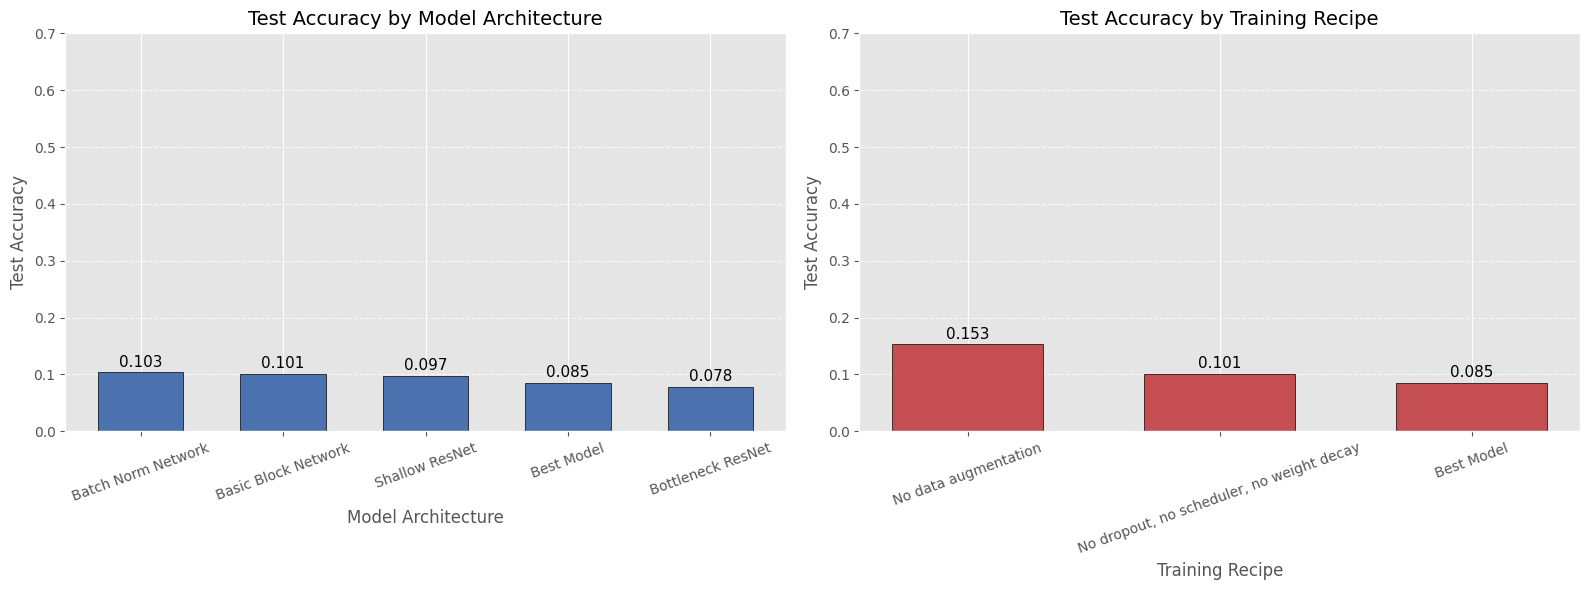

In [148]:
import matplotlib.pyplot as plt

# # Example dictionary
# models_performance = {
#     'model_B': {'test_accuracy': 0.646, 'flag': 'best', 'label': 'Best model'},
#     'model_C': {'test_accuracy': 0.607, 'flag': 'architecture', 'label': 'Shallow ResNet'},
#     'model_D': {'test_accuracy': 0.611, 'flag': 'architecture', 'label': 'Basic Block Net'},
#     'model_E': {'test_accuracy': 0.580, 'flag': 'architecture', 'label': 'Batch Norm Net'},
#     'model_F': {'test_accuracy': 0.600, 'flag': 'architecture', 'label': 'Bottleneck'},
#     'model_G': {'test_accuracy': 0.577, 'flag': 'recipes', 'label': 'No augmentation, overfitting'},
#     'model_H': {'test_accuracy': 0.493, 'flag': 'recipes', 'label': 'No dropout, no scheduler, no weight decay'}
# }

# Separate groups
architecture_group = []
recipes_group = []

for model, data in models_performance.items():
    if data['flag'] == 'architecture' or data['flag'] == 'best':
        architecture_group.append((data['test_accuracy'], data['label']))
    if data['flag'] == 'recipes' or data['flag'] == 'best':
        recipes_group.append((data['test_accuracy'], data['label']))

# Sort by decreasing accuracy
architecture_group = sorted(architecture_group, reverse=True)
recipes_group = sorted(recipes_group, reverse=True)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Architecture histogram
accuracies, labels = zip(*architecture_group)
bars = axes[0].bar(labels, accuracies, color='#4c72b0', width=0.6, edgecolor='black')
axes[0].set_xlabel('Model Architecture', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy by Model Architecture', fontsize=14)
axes[0].set_ylim(0, 0.7)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=11)

# Recipes histogram
accuracies, labels = zip(*recipes_group)
bars = axes[1].bar(labels, accuracies, color='#c44e52', width=0.6, edgecolor='black')
axes[1].set_xlabel('Training Recipe', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy by Training Recipe', fontsize=14)
axes[1].set_ylim(0, 0.7)
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `OxfordPetDataset`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters in order to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~90%.

In [149]:
def get_model(
        num_classes: int,
        weights: Optional[ResNet18_Weights] = None
    ) -> nn.Module:
    """Gets an image classifier based on ResNet-18.

    Args:
        num_classes: the number of classes.
        weights: pretrained weights to load into the network.
                 If None, the network is randomly initialized.

    Returns:
        The required network.
    """
    model = resnet18(weights=weights)
    # Here we override the old classifier
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

def set_requires_grad(layer: torch.nn.Module, train: bool) -> None:
    """Sets the requires_grad attribute to True or False for each parameter within a layer.

        Args:
            layer: the layer to freeze.
            train: if true train the layer.
    """
    for p in layer.parameters():
        p.requires_grad = train

In [150]:
# --- Fixed params ---

n_classes = OxfordPetDataset(split="train").get_num_classes()

# --- Configuration ---

cfg_2A = cfg_B

# --- DataLoaders ---

train_dl_2A, val_dl_2A, test_dl_2A = train_dl_B, val_dl_B, test_dl_B

# --- Model ---

weights = ResNet18_Weights.IMAGENET1K_V1
model_2A = get_model(n_classes, weights).to(device)

set_requires_grad(model_2A.conv1, False)
set_requires_grad(model_2A.bn1, False)
set_requires_grad(model_2A.layer1, False)
set_requires_grad(model_2A.layer2, False)
set_requires_grad(model_2A.layer3, False)
set_requires_grad(model_2A.layer4, False)

trainer_2A = Trainer(
    model=model_2A,
    train_loader=train_dl_2A,
    val_loader=val_dl_2A,
    test_loader=test_dl_2A,
    device=device,
    num_classes=n_classes,
    cfg=cfg_2A,
    verbose=False,
    model_file_name='model_2A'
)

# --- Training or Loading ---

if TRAINING_REQUIRED:
    trainer_2A.train()
else:
    trainer_2A.load("ckpts/model_2A.pth")

# --- Evaluation --- 
test_loss, test_accuracy = trainer_2A.eval("test")
print(f"Accuracy on the test set: {test_accuracy:.3f}")

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 0.821


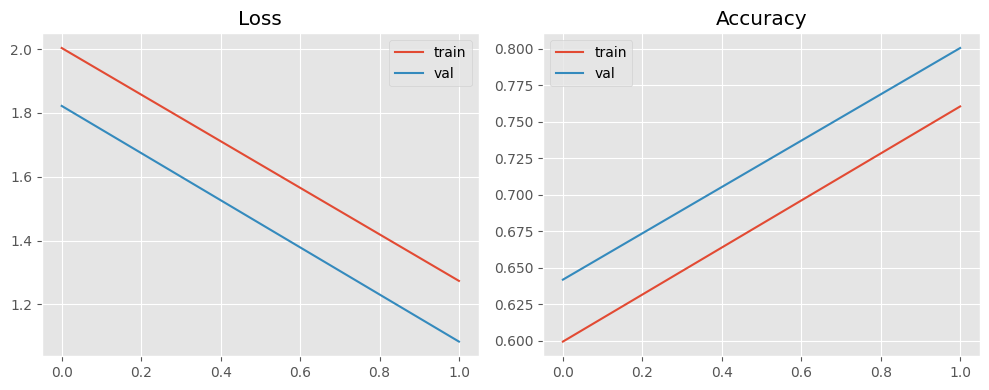

In [151]:
history_2A = {
    "train_loss":trainer_2A.train_loss,
    "train_acc":trainer_2A.train_acc,
    "val_loss":trainer_2A.val_loss,
    "val_acc":trainer_2A.val_acc
}

plot_history(history_2A)